### Overview

In this section, we will learn the basics of querying cloud-hosted data via [STAC](https://stacspec.org/en) and leverage parallel computing via [Dask](https://tutorial.xarray.dev/intermediate/xarray_and_dask.html).

We will learn how to query a catalog of Sentinel-2 images to find the least-cloudy scene over a chosen area, visualize it and download it as a GeoTIFF file.

### Setup

Determine our runtime environment.

In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

print(f'Environment: {environment}')

If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [ ]:
%%capture
if environment in ['colab', 'colab_enterprise']:
    !pip install pystac-client odc-stac rioxarray dask['distributed'] botocore \
      jupyter-server-proxy

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [ ]:
import dask
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import pystac_client
import rioxarray as rxr
import xarray as xr
from odc.stac import configure_s3_access, load

### Dask

[`Dask`](https://www.dask.org/) is a python library to run your computation in parallel across many machines. Dask has built-in support for key geospatial packages like XArray and Pandas allowing you to scale your computation easily. You can choose to run your code in parallel on your laptop, a machine in the cloud, local or cloud cluster of machines etc.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if environment == 'colab':
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

### Spatio Temporal Asset Catalog (STAC)

Spatio Temporal Asset Catalog (STAC) is an open standard for specifying and querying geospatial data. Data provider can share catalogs of satellite imagery ,climate datasets, LIDAR data, vector data etc. and specify asset metadata according to the STAC specifications. All STAC catalogs can be queried to find matching assets by time, location or metadata.


You can browse all available catalogs at https://stacindex.org/


Let's use [Earth Search by Element 84](https://stacindex.org/catalogs/earth-search#/) STAC API Catalog to look for items from the sentinel-2-l2a collection on AWS.


In [ ]:
catalog = pystac_client.Client.open(
    'https://earth-search.aws.element84.com/v1')

The STAC API Catalog offers several collections. Some of the collections are publicly-available (such as *Sentinel-2 Collection 1 Level-2A* (`sentinel-2-c1-l2a`)), while others are available in a [Requester Pays](https://docs.aws.amazon.com/AmazonS3/latest/userguide/RequesterPaysBuckets.html) bucket. To access data from a requester-pays bucket, you will need to ssupply your AWS credentials. Here we are accessing freely available data, so we set the configuration to not use credentials.

In [ ]:
configure_s3_access(
    aws_unsigned=True,
)

We define a location to get some satellite imagery.

In [ ]:
latitude = 27.163
longitude = 82.608

Define a GeoJSON geometry.


In [ ]:
geometry = {
    'type': 'Point',
    'coordinates': [longitude, latitude]
}

Search the catalog for matching items. See the documentation of the [`pystac_client.Client.search()`](https://pystac-client.readthedocs.io/en/latest/api.html#pystac_client.Client.search) method for details on the parameters and valid values.

In [ ]:
search = catalog.search(
    collections=['sentinel-2-c1-l2a'],
    intersects=geometry,
    datetime='2023-01-01/2023-12-31',
)
items = search.item_collection()
items

The `datatime` parameter can take a range or a single datetime. Here we specify `2023` which gets expanded to the range for the full year. We can also apply some additional metadata filters using the `query` parameter to look for images with less cloud cover and granules with less nodata pixels.

In [ ]:
search = catalog.search(
    collections=['sentinel-2-c1-l2a'],
    intersects=geometry,
    datetime='2023',
    query={
        'eo:cloud_cover': {'lt': 30},
        's2:nodata_pixel_percentage': {'lt': 10}
    }
)
items = search.item_collection()
items

We can also sort the results by some metadata. Here we sort by cloud cover.

In [ ]:
search = catalog.search(
    collections=['sentinel-2-c1-l2a'],
    intersects=geometry,
    datetime='2023',
    query={
        'eo:cloud_cover': {'lt': 30},
        's2:nodata_pixel_percentage': {'lt': 10}
    },
    sortby=[{'field': 'properties.eo:cloud_cover', 'direction': 'asc'}]

)
items = search.item_collection()
items

### Load STAC Images to XArray

Load the matching images as a XArray Dataset using [`odc.stac.load()`](https://odc-stac.readthedocs.io/en/latest/_api/odc.stac.load.html). We need to specify the required resolution and projection. This `crs` parameter in the function accepts a special value **utm** which automatically picks the appropriate UTM projection for the region.

In [ ]:
ds = load(
    items,
    bands=['red', 'green', 'blue', 'nir'],
    resolution=10,
    crs='utm',
    chunks={},  # <-- use Dask
    groupby='solar_day',
    preserve_original_order=True
)
ds

Use[ `xarray.Dataset.nbytes`](https://docs.xarray.dev/en/latest/generated/xarray.Dataset.nbytes.html) property to check the size of the loaded dataset.

In [ ]:
print(f'DataSet size: {ds.nbytes/1e6:.2f} MB.')

### Select a Single Scene

Let's work with a single scene for now. We will use the first item from our search (the least cloudy scene). When the items are loaded as a XArray Dataset, the `time` dimension is sorted. We get the timestamp of the least cloudy scene and select it from the dataset.

In [ ]:
timestamp = pd.to_datetime(items[0].properties['datetime']).tz_convert(None)
scene = ds.sel(time=timestamp)
scene

In [ ]:
print(f'Scene size: {scene.nbytes/1e6:.2f} MB.')

The Sentinel-2 scenes come with NoData value of 0. So we set the correct NoData value before further processing.

In [ ]:
scene = scene.where(scene != 0)
scene

Each band of the scene is saved with integer pixel values (data type `uint16`). This help save the storage cost as storing the reflectance values as floating point numbers (data type `float64`) requires more storage. We need to convert the raw pixel values to reflectances by applying the *scale* and *offset* values. The [Earth Search STAC API](https://github.com/Element84/earth-search) does not apply the scale/offset automatically to Sentinel-2 scene and they are supplied in the `raster:bands` metadata for each band. The scale and offset for sentinel-2 scenes captured after Jan 25, 2022 is `0.0001` and `-0.1` respectively.

In [ ]:
scale = 0.0001
offset = -0.1
scene = scene*scale + offset

This scene is small enough to fit into RAM, so we can load it into memory. As we setup a Dask LocalCluster, the process will be paralellized across all available cores of the machine. We can visualize the Dask graph to know the steps required to compute each chunk.

In [ ]:
dask.visualize(scene, optimize_graph=True, size='5x5')

Let's call `compute()` to kick-off the dask graph. Dask will query the cloud-hosted dataset to fetch the required pixels. Once you run the cell, look at the Dask Diagnostic Dashboard to see the data processing in action.

In [ ]:
%%time
scene = scene.compute()

In [ ]:
scene

### Visualize the Scene

We can create a low-resolution preview by resampling the DataArray from its native resolution. The raster metadata is stored in the [rio accessor](https://corteva.github.io/rioxarray/stable/rioxarray.html#rioxarray-rio-accessors). This is enabled by the `rioxarray` library which provides geospatial functions on top of xarray.

In [ ]:
print('CRS:', scene.rio.crs)
print('Resolution:', scene.rio.resolution())

This is a fairly large scene with a lot of pixels. For visualizing, we resample it to a lower resolution preview.

In [ ]:
preview = scene.rio.reproject(
    scene.rio.crs, resolution=300
)
preview

To visualize our Dataset, we first convert it to a DataArray using the `to_array()` method. All the variables will be converted to a new dimension. Since our variables are image bands, we give the name of the new dimesion as band.


In [ ]:
preview_da = preview.to_array('band')
preview_da

Let's visualize the scene with RGB bands.

In [ ]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5,5)
preview_da.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax)
ax.set_title('RGB Visualization')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()

We can improve the contrast by supplying the `vmin` and `vmax` values. Typical range of reflectances is between 0-0.3 so we apply those.

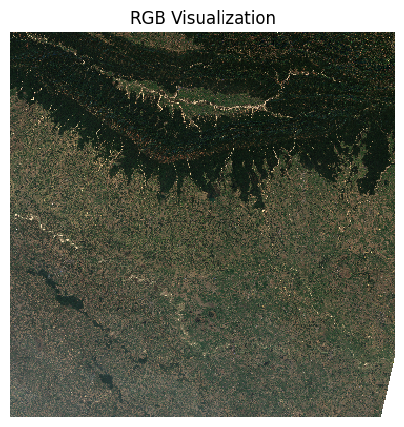

In [29]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5,5)
preview_da.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax,
    vmin=0,
    vmax=0.3)
ax.set_title('RGB Visualization')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()

When plotting the image, we can supply `robust=True` option applies a *98-percentile* stretch to find the optimal min/max values for visualization.

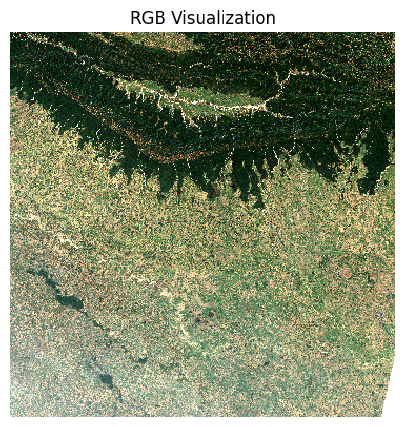

In [30]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(5,5)
preview_da.sel(band=['red', 'green', 'blue']).plot.imshow(
    ax=ax,
    robust=True)
ax.set_title('RGB Visualization')
ax.set_axis_off()
ax.set_aspect('equal')
plt.show()

Close the dask client. This presents multiple clients being instantiated when running different notebooks on the same machine.

In [ ]:
client.shutdown()

### Exercise

The `items` variable contains a list of STAC Items returned by the query. The code below iterates through each item and print its metadata stored in the `properties`. Extract the Sentinel-2 Product ID stored in `s2:product_uri` peroperty and print a list of all image ids returned by the query.

In [ ]:
for item in items:
  print(item.properties)